# Titanic Survived _ Logistic Regression
- 타이타닉 탑승객 데이터를 기반으로 생존 여부를 예측한다.

## 필요한 항목
- Survived(결과값)
- Pclass : 상류층일 수록 구명정 접근 쉬워서 생존률 상승
- Sex : 여성 생존률이 높은편
- Age : 어린아이 및 노약자 우선 구조 정책으로 영향있다
- SibSp(형제/배우자수) : 가족이 많으면 함께 행동해서 행동패턴 달라진다.
- Parch(부모/자녀수) : 위와 같은 이유
- Fare(운임비용) : 요금이 높을 수록 상류층이고 구조 가능성 올라간다.
- Embarked(탑승항구) : 지역별로 상류층 비율이 다르다.

## 필요없는 항목
- Passenger ID : 상관관계가 없다.
- Ticket(티켓번호) : 상관관계가 없다.
- Name : 상관관계가 없다.
- Cabin(객실번호) : 결측치 너무 많아서 쓸모가 없다.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 모든 행과 열을 다 보이게 설정
# pd.set_option('display.max_rows', None)   # 행 전체 보기
# pd.set_option('display.max_columns', None)  # 열 전체 보기

data = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

data



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 1.데이터 전처리 실행

In [2]:
# 사용할 컬럼만 선택
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
data


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


### 결측치 처리

In [3]:
# 결측치 처리
# 수치형 데이터는 평균값, 중앙값을 보통 이용한다.
# 범주형 데이터는 최빈값을 보통 이용한다.
data.loc[:, 'Age'] = data['Age'].fillna(data['Age'].mean())
data.loc[:, 'Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data


# Embarked : S / C / Q

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S
887,1,1,female,19.000000,0,0,30.0000,S
888,0,3,female,29.699118,1,2,23.4500,S
889,1,1,male,26.000000,0,0,30.0000,C


### 이상치 처리
- 이상치가 나올 수 있는 카테고리는 Fare와 Age 인데, 170살 이런 데이터는 없으며 Fare는 정확히 기록되었을 값이기 때문에 이상치는 없다고 보는게 타당하다.
- 나이에서 소수점은 개월수이다.


### 범주형 데이터의 One-Hot Encoding
- Sex, Embarked 데이터를 인코딩한다

In [4]:

# 범주형 변수 원핫 인코딩
data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)
# drop_first는 중복되는 컬럼을 제거한다. (Sex_Female을 지운것이다.)
print(data.columns)


Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [5]:
data

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,True,False,True
1,1,1,38.000000,1,0,71.2833,False,False,False
2,1,3,26.000000,0,0,7.9250,False,False,True
3,1,1,35.000000,1,0,53.1000,False,False,True
4,0,3,35.000000,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,True,False,True
887,1,1,19.000000,0,0,30.0000,False,False,True
888,0,3,29.699118,1,2,23.4500,False,False,True
889,1,1,26.000000,0,0,30.0000,True,False,False


### 입력, 출력값 정리

In [6]:
# 입력(X), 출력(y) 분리
X = data.drop('Survived', axis=1).values
y = data['Survived'].values.reshape(-1, 1)



In [7]:
X

array([[3, 22.0, 1, ..., True, False, True],
       [1, 38.0, 1, ..., False, False, False],
       [3, 26.0, 0, ..., False, False, True],
       ...,
       [3, 29.69911764705882, 1, ..., False, False, True],
       [1, 26.0, 0, ..., True, False, False],
       [3, 32.0, 0, ..., True, True, False]], dtype=object)

### 스케일링

In [8]:
# 데이터 정규화 (스케일링)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X
# 스케일링 안하면 값이 큰 데이터 카테고리가 모델에서 영향력이 강해져. 결과값이 편향될 수 있다. 
# 그래서 스케일링을 한다.


array([[ 0.82737724, -0.5924806 ,  0.43279337, ...,  0.73769513,
        -0.30756234,  0.61583843],
       [-1.56610693,  0.63878901,  0.43279337, ..., -1.35557354,
        -0.30756234, -1.62380254],
       [ 0.82737724, -0.2846632 , -0.4745452 , ..., -1.35557354,
        -0.30756234,  0.61583843],
       ...,
       [ 0.82737724,  0.        ,  0.43279337, ..., -1.35557354,
        -0.30756234,  0.61583843],
       [-1.56610693, -0.2846632 , -0.4745452 , ...,  0.73769513,
        -0.30756234, -1.62380254],
       [ 0.82737724,  0.17706291, -0.4745452 , ...,  0.73769513,
         3.25137334, -1.62380254]])

### 학습 데이터, 테스트 데이터 준비 

In [9]:
# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 데이터 중에서 20%는 테스트 용, 80%는 학습 용으로 분리

## 2. Logistic Regression 구현
- 선형식 모델 : z=w1*x1 + w2*x2 + w3*x3 + w4*x4 + w5*x5 + w6*x6 + w7*x7+ w8*x8 + b
- 시그모이드 함수 : y= 1 / (1+e^(-z))
- 손실 함수 : Cross Binary Entropy 사용
- 손실함수에 Gradiant Descent 사용하여 가중치/bias 최적화
- 
- 

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_pred):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_pred+1e-8) + (1-y)*np.log(1-y_pred+1e-8))
    #log함수가 0을 입력으로 받지 않게 하려고 1e-8 사용.
    
def logistic_regression(X, y, alpha=0.01, epochs=1000, batch_size=None): #alpha는 학습률, epoch는 학습 횟수, batch_size는 mini-batch 사용시 사용.
    m, n = X.shape
    W = np.zeros((n, 1))
    b = 0

    losses = []

    for epoch in range(epochs):
        epoch_loss = 0

        # Full-batch, Mini-batch 여부에 따라 데이터를 나눈다.
        if batch_size is None:  # Full batch
            X_batches = [X]
            y_batches = [y]
        else:  # Mini-batch
            X_batches = [X[i:i+batch_size] for i in range(0, m, batch_size)]
            y_batches = [y[i:i+batch_size] for i in range(0, m, batch_size)]

        # 각 배치마다 업데이트 수행
        for X_batch, y_batch in zip(X_batches, y_batches):
            # Forward
            z = np.dot(X_batch, W) + b
            y_pred = sigmoid(z)

            # Loss
            loss = compute_loss(y_batch, y_pred) #compute_loss는 평균값을 반환.
            epoch_loss += loss * len(y_batch) #Mini-batch의 경우 batch_size별로 묶이므로 합산한다.

            # 경사하강법을 이용하여 가중치아 bias 업데이트
            dW = (1/len(y_batch)) * np.dot(X_batch.T, (y_pred - y_batch))
            db = (1/len(y_batch)) * np.sum(y_pred - y_batch)

            
            W = W - alpha * dW
            b = b - alpha * db

        # epoch 평균 손실 저장
        losses.append(epoch_loss / m) #Mini-batch를 고려하여  epoch_loss 사용

    return W, b, losses

## 3. 모델 학습 및 평가

In [11]:
# Full-batch
W_full, b_full, loss_full = logistic_regression(X_train, y_train, alpha=0.01, epochs=500, batch_size=None)

# Mini-batch 32
W_mini32, b_mini32, loss_mini32 = logistic_regression(X_train, y_train, alpha=0.01, epochs=500, batch_size=32)

# Mini-batch 64
W_mini64, b_mini64, loss_mini64 = logistic_regression(X_train, y_train, alpha=0.01, epochs=500, batch_size=64)


In [12]:
def model_predict(X,W,b):
    y_pred=sigmoid(np.dot(X,W)+b)
    return (y_pred>=0.5).astype(int)

In [13]:
y_pred_full = model_predict(X_test, W_full, b_full) #모델을 통해 예측한 Y값
accuracy_full = np.mean(y_pred_full == y_test) 
#실제 X_test에 대한 결과값과 얼마나 일치하는지 정확도 확인


y_pred_32 = model_predict(X_test, W_mini32, b_mini32)
accuracy_32 = np.mean(y_pred_32 == y_test)
#실제 X_test에 대한 결과값과 얼마나 일치하는지 정확도 확인

y_pred_64 = model_predict(X_test, W_mini64, b_mini64)
accuracy_64 = np.mean(y_pred_64 == y_test) #
#실제 X_test에 대한 결과값과 얼마나 일치하는지 정확도 확인



In [14]:
print("Full-batch Accuracy : ",accuracy_full)
print("Mini-batch 32 Accuracy : ",accuracy_32)
print("Mini-batch 64 Accuracy : ",accuracy_64)

Full-batch Accuracy :  0.7877094972067039
Mini-batch 32 Accuracy :  0.7988826815642458
Mini-batch 64 Accuracy :  0.7932960893854749


- 약 80%의 적중률을 보이는 모델이다.

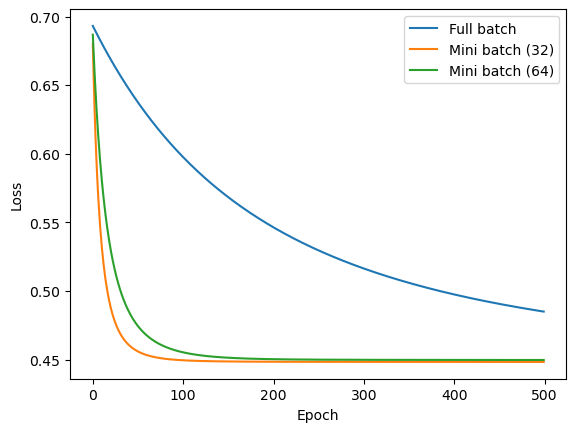

In [15]:


plt.plot(loss_full, label='Full batch')
plt.plot(loss_mini32, label='Mini batch (32)')
plt.plot(loss_mini64, label='Mini batch (64)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

- 위 그래프를 통해서 Mini-batch가 Full-batch보다 모델의 성능을 향상시킨다는 것을 알 수 있다.
- Epoch가 적은 경우에는 Mini-batch가 Loss를 줄이는데 효과적이다